# Week 9 — Task 1.1 (Gaussian Noise)

**Goal:** Apply Gaussian noise with different mean and variance values to the same input image, and observe:
1. the noisy image,
2. its histogram,
3. how changing mean/variance affects the result.

This notebook section completes **Task 1.1** with **five parameter combinations**.

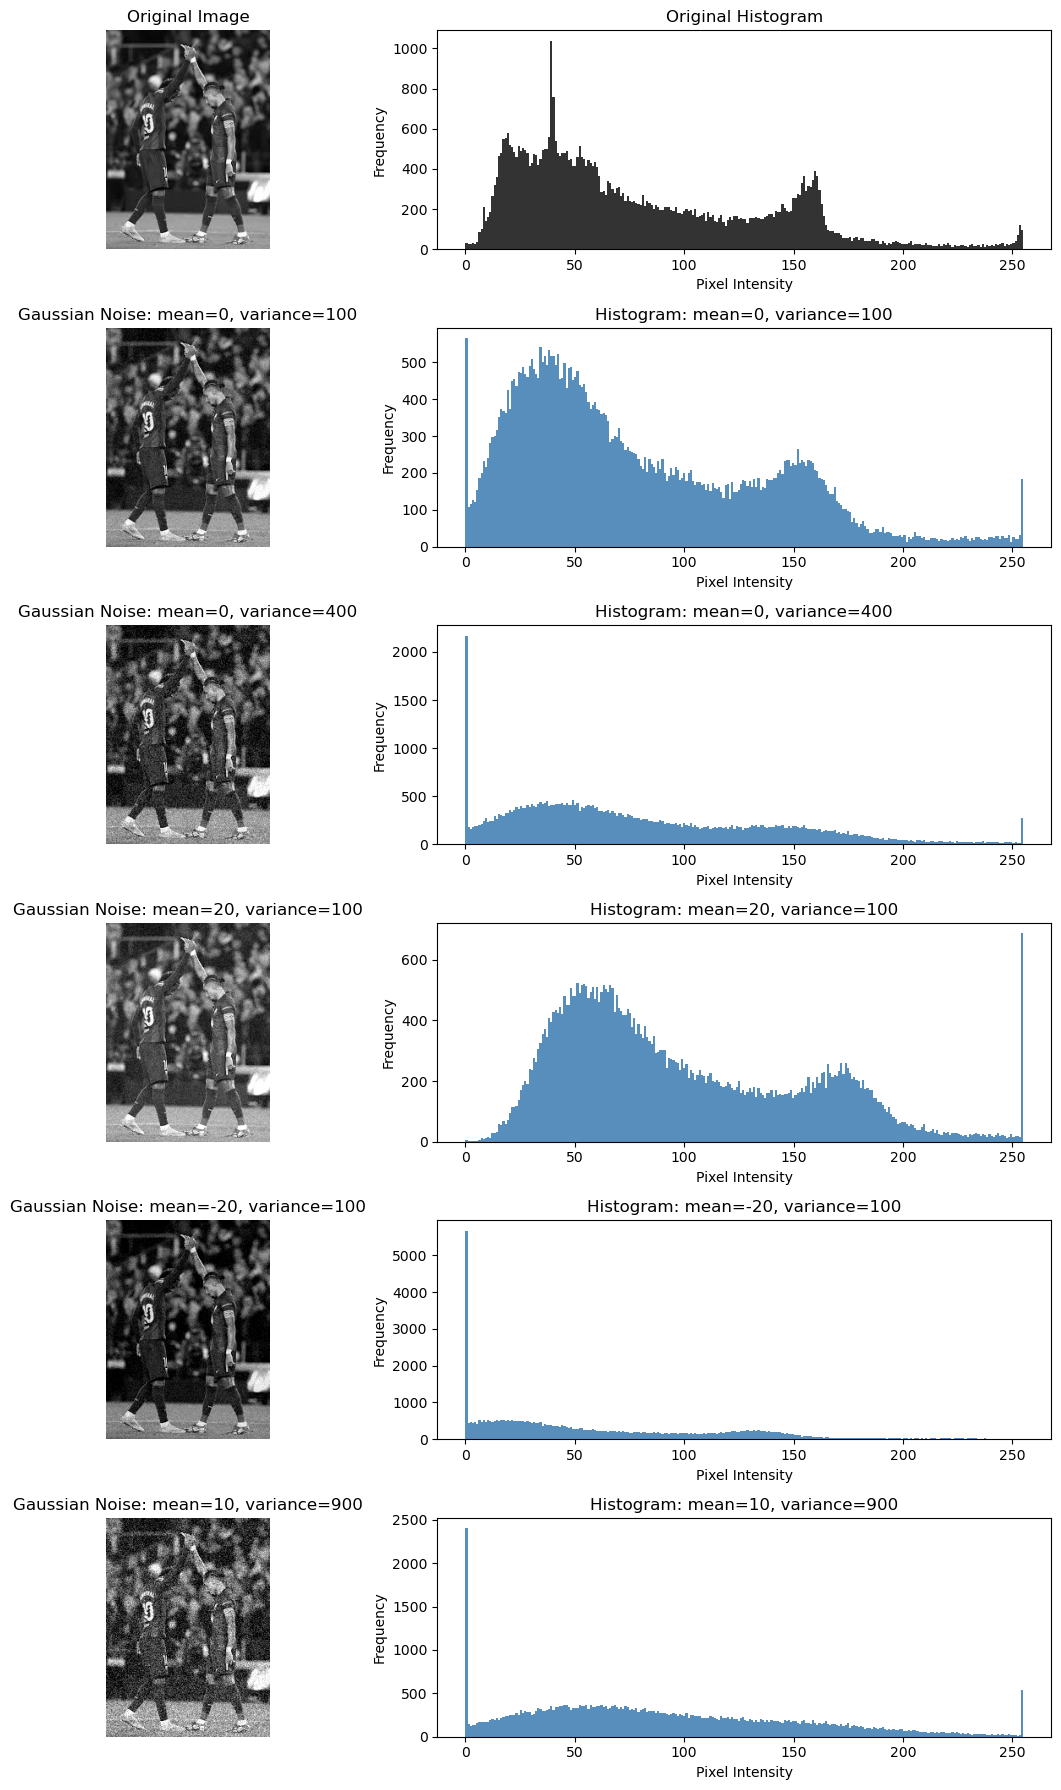

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

# -----------------------------
# Function: Add Gaussian noise
# -----------------------------
def add_gaussian_noise(image, mean=0.0, variance=100.0):
    """
    Add Gaussian noise to an image.

    Parameters
    ----------
    image : np.ndarray
        Input grayscale image in [0, 255].
    mean : float
        Mean of Gaussian noise.
    variance : float
        Variance of Gaussian noise.

    Returns
    -------
    noisy_image : np.ndarray
        Noisy image clipped to [0, 255], dtype uint8.
    """
    sigma = np.sqrt(variance)
    noise = np.random.normal(loc=mean, scale=sigma, size=image.shape)
    noisy = image.astype(np.float64) + noise
    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)


# Use a fixed seed for reproducibility
np.random.seed(42)

# Input image (grayscale)
image = io.imread('images.jpg')
if image.ndim == 3:
    image = (color.rgb2gray(image) * 255).astype(np.uint8)
else:
    image = image.astype(np.uint8)

# At least five (mean, variance) combinations for Task 1.1
param_sets = [
    (0, 100),
    (0, 400),
    (20, 100),
    (-20, 100),
    (10, 900),
]

# Display original + noisy images and histograms
fig, axes = plt.subplots(len(param_sets) + 1, 2, figsize=(12, 3 * (len(param_sets) + 1)))

# Original image and histogram
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(image.ravel(), bins=256, range=(0, 255), color='black', alpha=0.8)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

for i, (mean, var) in enumerate(param_sets, start=1):
    noisy_img = add_gaussian_noise(image, mean=mean, variance=var)

    axes[i, 0].imshow(noisy_img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Gaussian Noise: mean={mean}, variance={var}')
    axes[i, 0].axis('off')

    axes[i, 1].hist(noisy_img.ravel(), bins=256, range=(0, 255), color='steelblue', alpha=0.9)
    axes[i, 1].set_title(f'Histogram: mean={mean}, variance={var}')
    axes[i, 1].set_xlabel('Pixel Intensity')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Observations (Task 1.1)

1. **Increasing variance** (e.g., 100 → 400 → 900) makes the image visibly grainier and spreads the histogram wider.
2. **Positive mean** shifts intensities to the right (brighter image); histogram center moves toward higher gray levels.
3. **Negative mean** shifts intensities to the left (darker image); histogram center moves toward lower gray levels.
4. With very high variance, fine details become less clear because noise dominates local texture.
5. All noisy results remain in valid range 
$[0,255]$ due to clipping.

# Task 1.2 — Salt & Pepper Noise

**Goal:** Apply salt and pepper noise with different probabilities for salt and pepper to the same input image, and observe the image, histogram, and differences.

This notebook section completes **Task 1.2** with **five probability combinations**.

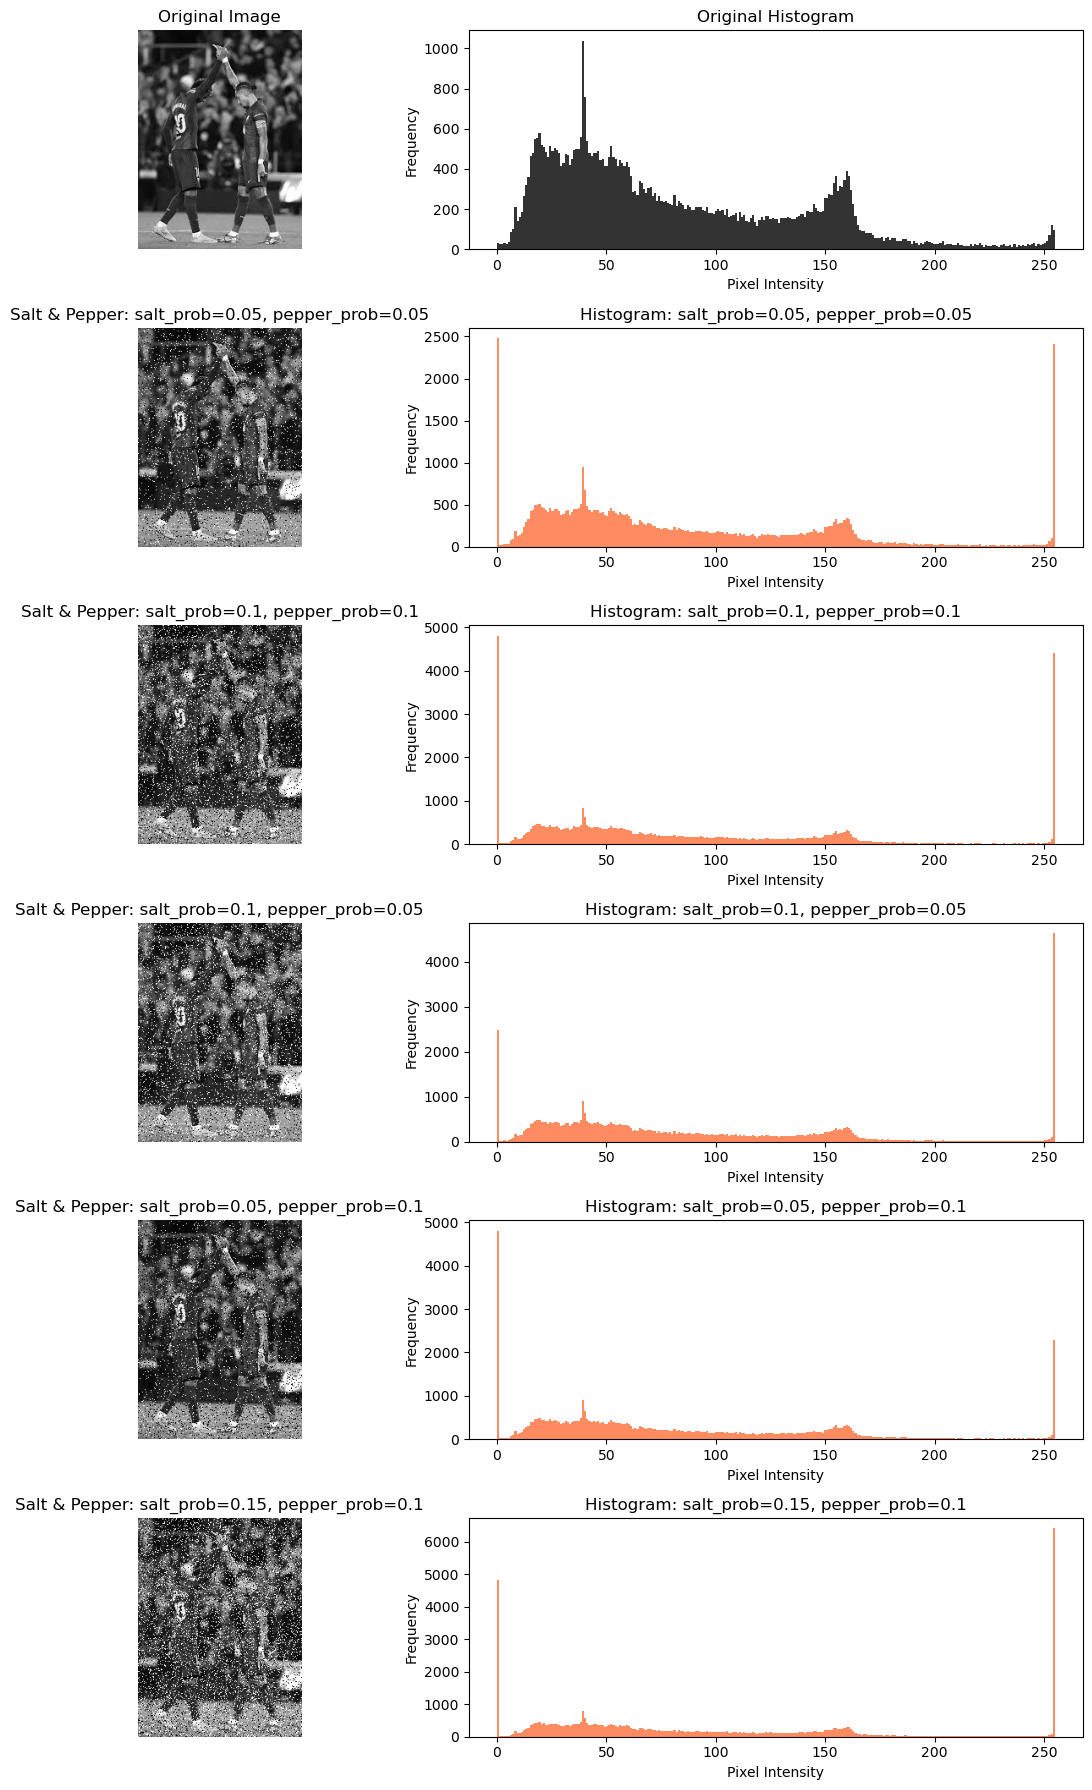

In [36]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    """
    Adds Salt & Pepper noise to an image.

    Parameters
    ----------
    image : np.ndarray
        Input image in [0, 255].
    salt_prob : float
        Probability of adding salt (white) noise (0 to 1).
    pepper_prob : float
        Probability of adding pepper (black) noise (0 to 1).

    Returns
    -------
    noisy_image : np.ndarray
        Image with salt & pepper noise applied, dtype uint8.
    """
    noisy_image = image.copy()
    
    # Salt noise (white pixels - 255)
    num_salt = int(np.ceil(salt_prob * image.size))
    salt_coords = [np.random.randint(0, i, size=num_salt) for i in image.shape]
    noisy_image[salt_coords[0], salt_coords[1]] = 255
    
    # Pepper noise (black pixels - 0)
    num_pepper = int(np.ceil(pepper_prob * image.size))
    pepper_coords = [np.random.randint(0, i, size=num_pepper) for i in image.shape]
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0
    
    return noisy_image


# Reset seed for reproducibility
np.random.seed(42)

# Five (salt_prob, pepper_prob) combinations for Task 1.2
salt_pepper_sets = [
    (0.05, 0.05),      # Equal, small
    (0.1, 0.1),        # Equal, moderate
    (0.1, 0.05),       # More salt
    (0.05, 0.1),       # More pepper
    (0.15, 0.1),       # Higher salt
]

# Display original + noisy images and histograms
fig, axes = plt.subplots(len(salt_pepper_sets) + 1, 2, figsize=(12, 3 * (len(salt_pepper_sets) + 1)))

# Original image and histogram
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(image.ravel(), bins=256, range=(0, 255), color='black', alpha=0.8)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

for i, (salt_p, pepper_p) in enumerate(salt_pepper_sets, start=1):
    noisy_sp = add_salt_pepper_noise(image, salt_prob=salt_p, pepper_prob=pepper_p)
    
    axes[i, 0].imshow(noisy_sp, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Salt & Pepper: salt_prob={salt_p}, pepper_prob={pepper_p}')
    axes[i, 0].axis('off')
    
    axes[i, 1].hist(noisy_sp.ravel(), bins=256, range=(0, 255), color='coral', alpha=0.9)
    axes[i, 1].set_title(f'Histogram: salt_prob={salt_p}, pepper_prob={pepper_p}')
    axes[i, 1].set_xlabel('Pixel Intensity')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Observations (Task 1.2)

1. **Salt & Pepper noise** creates impulsive noise — sharp white (255) or black (0) pixels randomly scattered.
2. **Increasing probabilities** makes the noise more visible; fine details are obscured by random peaks/valleys.
3. **Asymmetric probabilities** (e.g., salt > pepper) create more white spots, shifting histogram toward extremes.
4. **Histograms** show sharp spikes at 0 (pepper) and 255 (salt), with diminished mid-tone values.
5. This noise type is distinctly different from Gaussian noise — it's **impulsive** rather than smooth.

# Task 1.3 — Uniform Noise

**Goal:** Apply uniform noise with different low and high values to the same input image, and observe the image, histogram, and differences.

This notebook section completes **Task 1.3** with **five parameter combinations**.

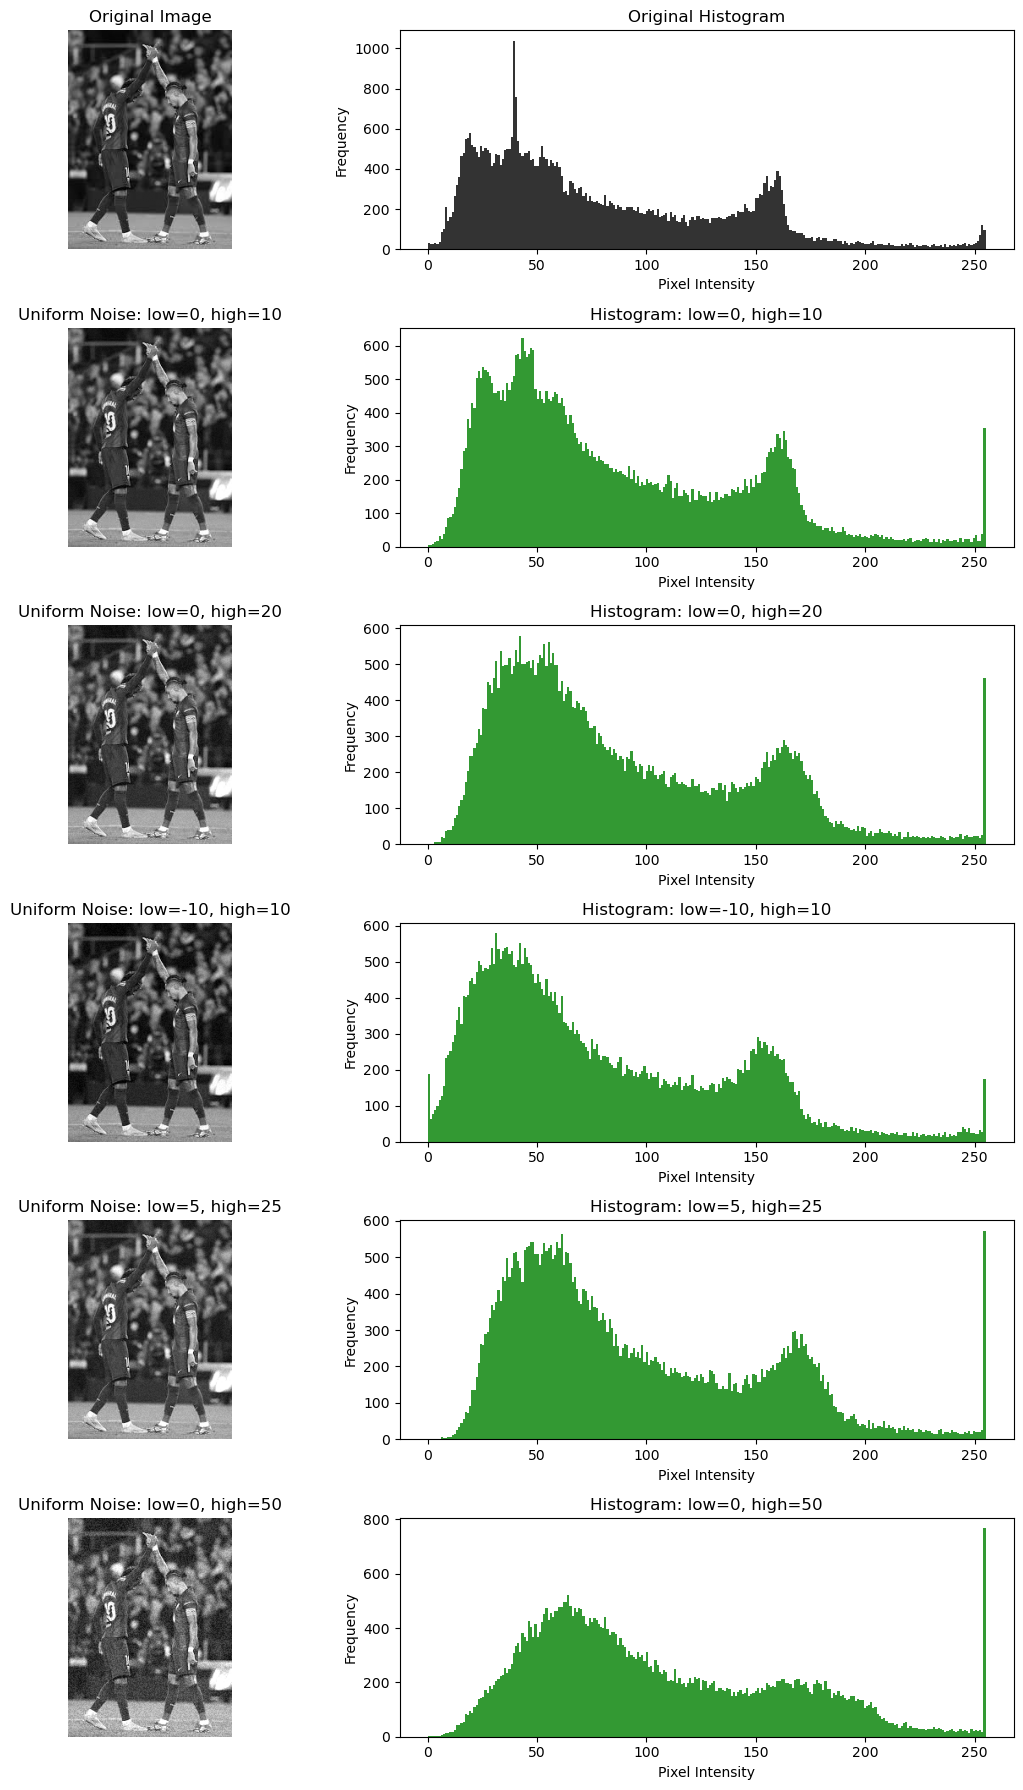

In [37]:
def add_uniform_noise(image, low=0, high=10):
    """
    Adds Uniform noise to an image.

    Parameters
    ----------
    image : np.ndarray
        Input image in [0, 255].
    low : float
        Lower bound of the uniform noise.
    high : float
        Upper bound of the uniform noise.

    Returns
    -------
    noisy_image : np.ndarray
        Image with added uniform noise, clipped to [0, 255], dtype uint8.
    """
    uniform_noise = np.random.uniform(low, high, image.shape)
    noisy_image = image.astype(np.float64) + uniform_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)


# Reset seed for reproducibility
np.random.seed(42)

# Five (low, high) combinations for Task 1.3
uniform_sets = [
    (0, 10),      # Small range
    (0, 20),      # Moderate range
    (-10, 10),    # Centered range
    (5, 25),      # Higher range, positive offset
    (0, 50),      # Large range
]

# Display original + noisy images and histograms
fig, axes = plt.subplots(len(uniform_sets) + 1, 2, figsize=(12, 3 * (len(uniform_sets) + 1)))

# Original image and histogram
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(image.ravel(), bins=256, range=(0, 255), color='black', alpha=0.8)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

for i, (low_val, high_val) in enumerate(uniform_sets, start=1):
    noisy_uniform = add_uniform_noise(image, low=low_val, high=high_val)
    
    axes[i, 0].imshow(noisy_uniform, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Uniform Noise: low={low_val}, high={high_val}')
    axes[i, 0].axis('off')
    
    axes[i, 1].hist(noisy_uniform.ravel(), bins=256, range=(0, 255), color='green', alpha=0.8)
    axes[i, 1].set_title(f'Histogram: low={low_val}, high={high_val}')
    axes[i, 1].set_xlabel('Pixel Intensity')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Observations (Task 1.3)

1. **Uniform noise range** directly controls the amount of intensity variation added to the image.
2. **Smaller ranges** (low=0, high=10) produce subtle noise; histograms broaden slightly but maintain original distribution.
3. **Larger ranges** (low=0, high=50) create visible intensity shift and histogram spread across wider regions.
4. **Negative low values** (e.g., low=-10, high=10) center the noise around zero, producing both brightening and darkening.
5. **Positive offset** (low=5, high=25) shifts overall intensity upward, creating a brighter noisy image.
6. Uniform noise creates a **smooth spread** in the histogram (unlike salt & pepper's discrete spikes).

# Task 1.4 — Remaining Noise Types (Rayleigh & Exponential)

**Goal:** Apply Rayleigh and Exponential noise types to the same input image, and observe the image, histogram, and differences.

This notebook section completes **Task 1.4** with both remaining noise types.

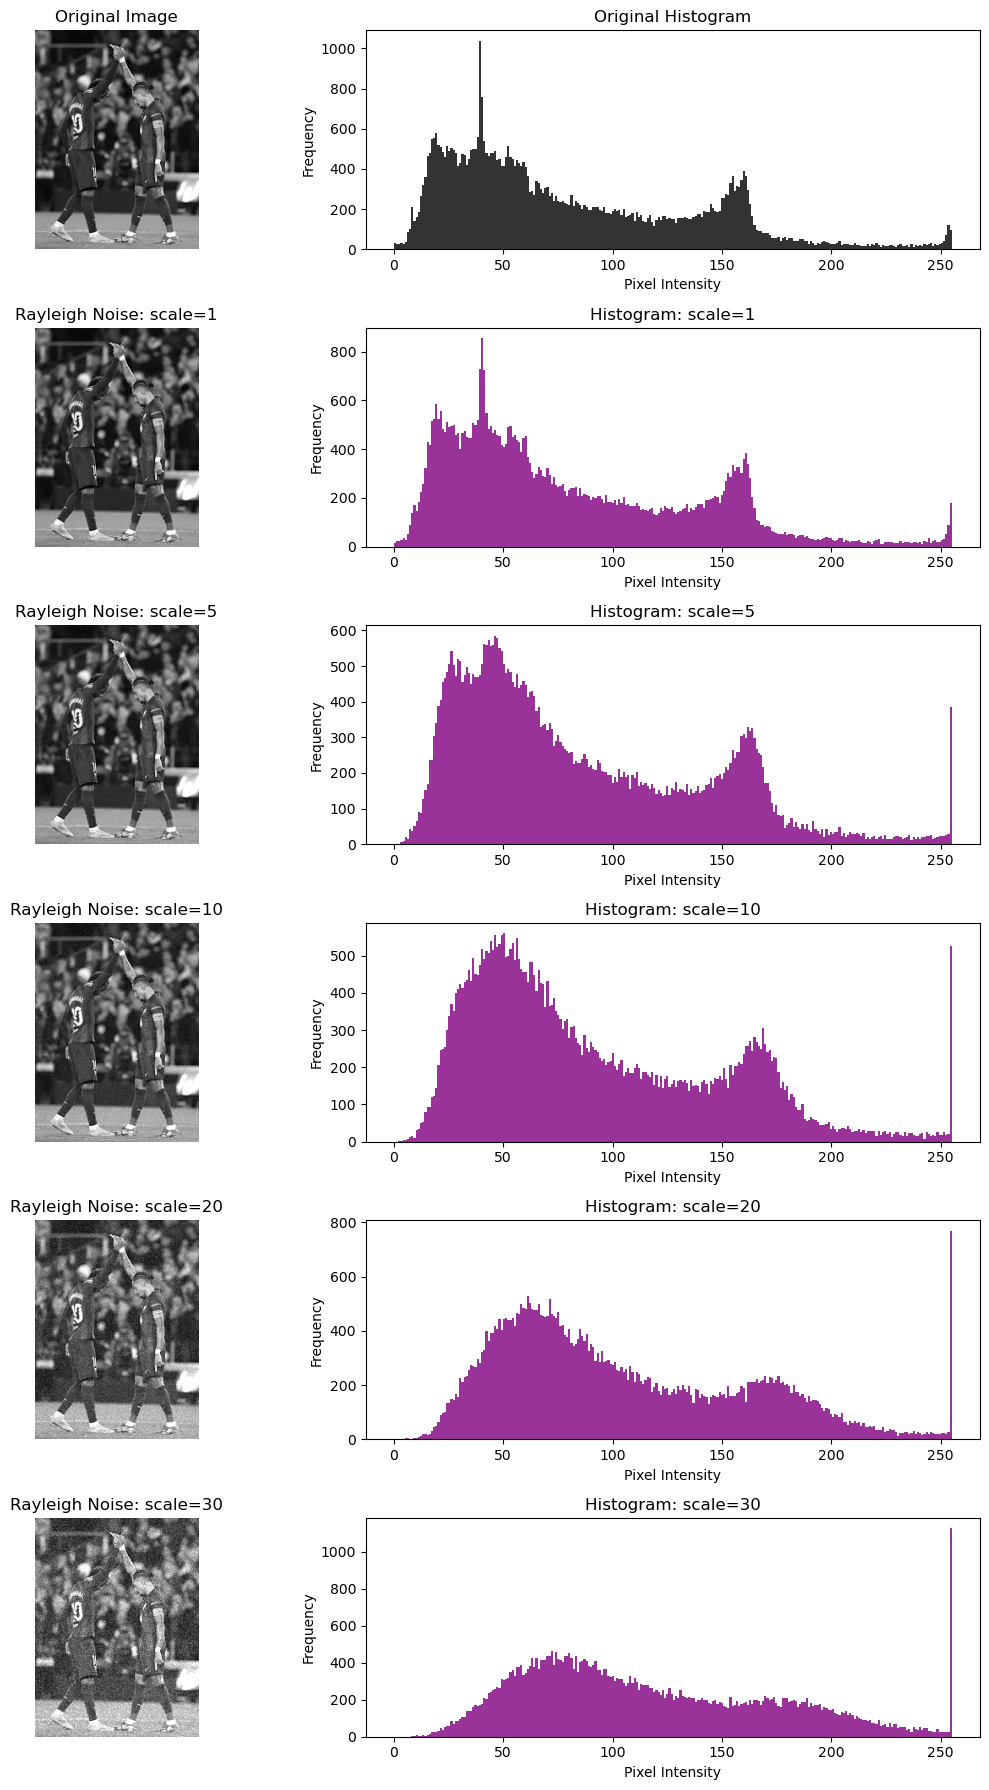

Rayleigh Noise Analysis: Larger scale values increase overall brightness and noise intensity.


In [38]:
## A. Rayleigh Noise

def add_rayleigh_noise(image, scale=1):
    """
    Adds Rayleigh noise to an image.
    
    Rayleigh noise follows a Rayleigh probability distribution.
    It is common in radar systems and is asymmetric (skewed toward positive values).

    Parameters
    ----------
    image : np.ndarray
        Input image in [0, 255].
    scale : float
        Scale parameter for the Rayleigh distribution.

    Returns
    -------
    noisy_image : np.ndarray
        Image with added Rayleigh noise, clipped to [0, 255], dtype uint8.
    """
    rayleigh_noise = np.random.rayleigh(scale=scale, size=image.shape)
    noisy_image = image.astype(np.float64) + rayleigh_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)


# Reset seed for reproducibility
np.random.seed(42)

# Five different scale values for Rayleigh noise
rayleigh_scales = [1, 5, 10, 20, 30]

# Display original + noisy images and histograms
fig, axes = plt.subplots(len(rayleigh_scales) + 1, 2, figsize=(12, 3 * (len(rayleigh_scales) + 1)))

# Original image and histogram
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(image.ravel(), bins=256, range=(0, 255), color='black', alpha=0.8)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

for i, scale_val in enumerate(rayleigh_scales, start=1):
    noisy_rayleigh = add_rayleigh_noise(image, scale=scale_val)
    
    axes[i, 0].imshow(noisy_rayleigh, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Rayleigh Noise: scale={scale_val}')
    axes[i, 0].axis('off')
    
    axes[i, 1].hist(noisy_rayleigh.ravel(), bins=256, range=(0, 255), color='purple', alpha=0.8)
    axes[i, 1].set_title(f'Histogram: scale={scale_val}')
    axes[i, 1].set_xlabel('Pixel Intensity')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Rayleigh Noise Analysis: Larger scale values increase overall brightness and noise intensity.")

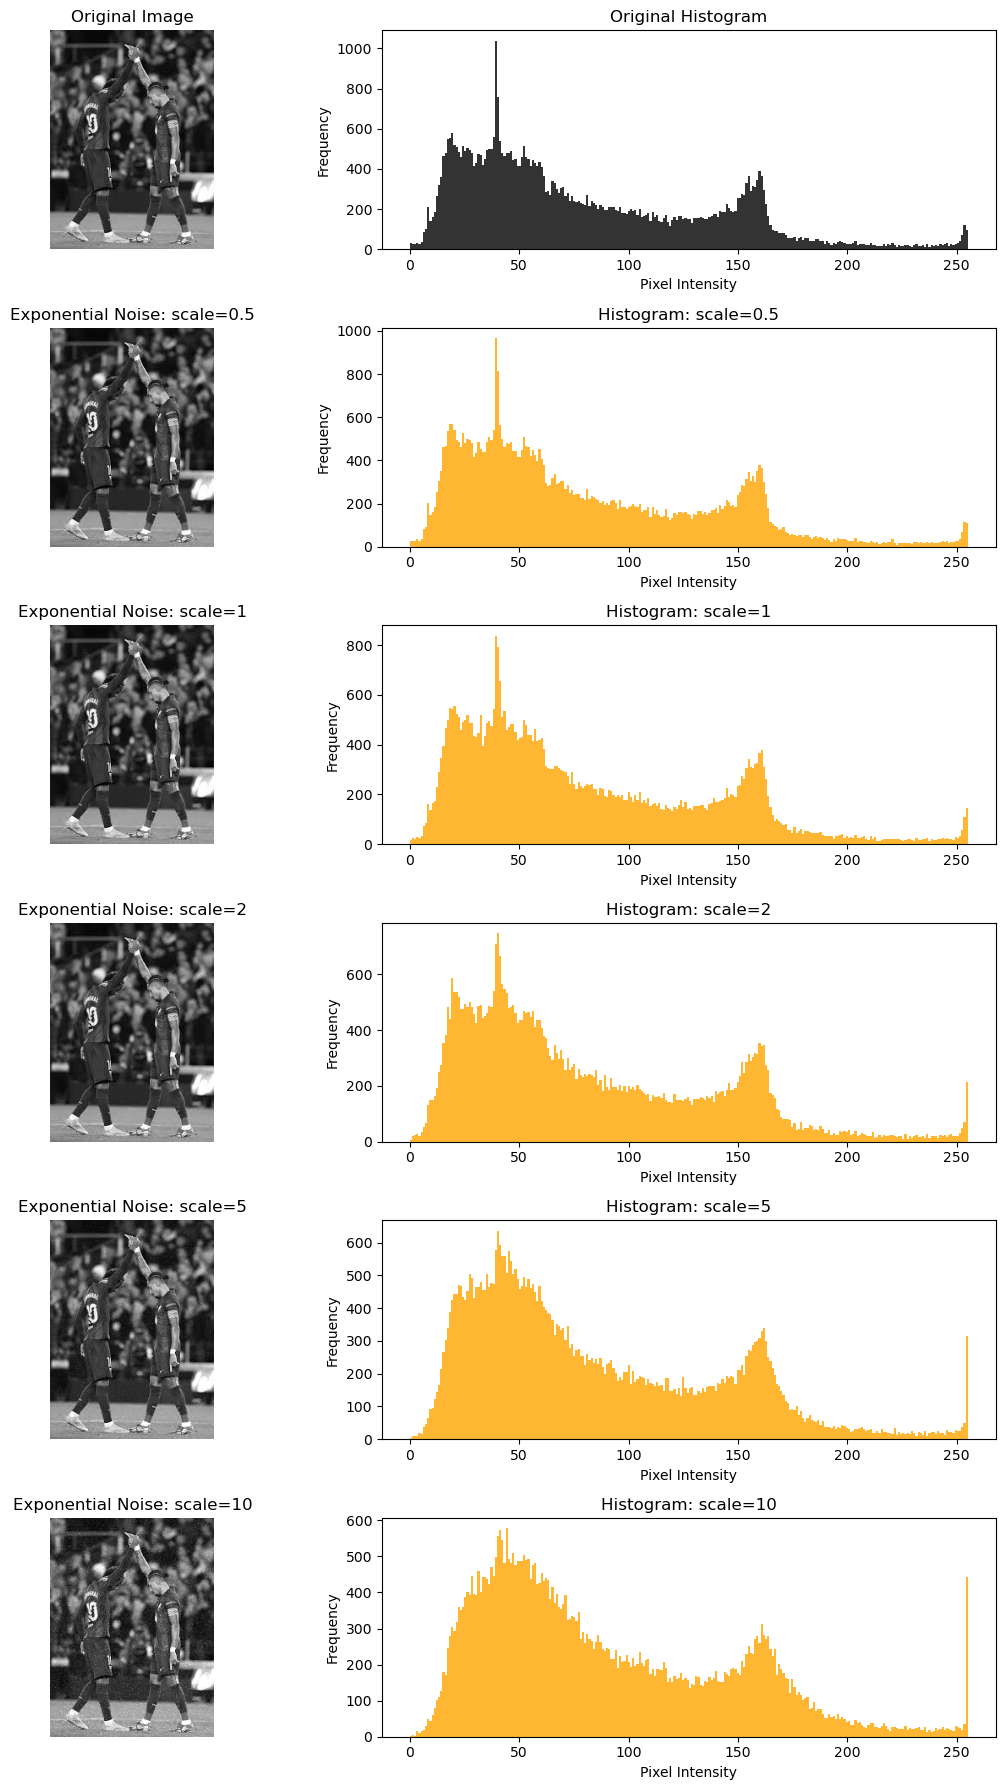

Exponential Noise Analysis: Exponential noise is skewed and tends to brighten the image, with more variation at higher scales.


In [39]:
## B. Exponential Noise

def add_exponential_noise(image, scale=1):
    """
    Adds Exponential noise to an image.
    
    Exponential noise follows an exponential distribution.
    It is typically asymmetric and concentrated in lower values.

    Parameters
    ----------
    image : np.ndarray
        Input image in [0, 255].
    scale : float
        Scale parameter for the Exponential distribution.

    Returns
    -------
    noisy_image : np.ndarray
        Image with added Exponential noise, clipped to [0, 255], dtype uint8.
    """
    exponential_noise = np.random.exponential(scale=scale, size=image.shape)
    noisy_image = image.astype(np.float64) + exponential_noise
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)


# Reset seed for reproducibility
np.random.seed(42)

# Five different scale values for Exponential noise
exponential_scales = [0.5, 1, 2, 5, 10]

# Display original + noisy images and histograms
fig, axes = plt.subplots(len(exponential_scales) + 1, 2, figsize=(12, 3 * (len(exponential_scales) + 1)))

# Original image and histogram
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(image.ravel(), bins=256, range=(0, 255), color='black', alpha=0.8)
axes[0, 1].set_title('Original Histogram')
axes[0, 1].set_xlabel('Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')

for i, scale_val in enumerate(exponential_scales, start=1):
    noisy_exponential = add_exponential_noise(image, scale=scale_val)
    
    axes[i, 0].imshow(noisy_exponential, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(f'Exponential Noise: scale={scale_val}')
    axes[i, 0].axis('off')
    
    axes[i, 1].hist(noisy_exponential.ravel(), bins=256, range=(0, 255), color='orange', alpha=0.8)
    axes[i, 1].set_title(f'Histogram: scale={scale_val}')
    axes[i, 1].set_xlabel('Pixel Intensity')
    axes[i, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Exponential Noise Analysis: Exponential noise is skewed and tends to brighten the image, with more variation at higher scales.")

## Observations (Task 1.4)

**Rayleigh Noise:**
1. Rayleigh noise is **asymmetric** — it always produces non-negative values.
2. Increasing scale parameter brightens the image; histogram shifts rightward.
3. At higher scales (scale=20, 30), the image becomes noticeably brighter and noisier.
4. The distribution appears **skewed toward higher intensities**, unlike Gaussian noise.
5. Commonly occurs in radar and microwave imaging systems.

**Exponential Noise:**
1. Exponential noise is also **asymmetric** with values concentrated at lower end of the distribution.
2. Small scales (0.5, 1) produce subtle brightening.
3. Larger scales (5, 10) create strong brightness increase and visible grain.
4. Histogram shows **rightward skew** with a tail extending to 255.
5. Appears to preserve edge structure better than Gaussian noise but creates intensity variations.

# Task 2 — Implementing Filters for Image Restoration

This section implements mean filters, order-statistic filters, and harmonic mean filters for denoising.

## Filter Implementations

In [40]:
import copy
from scipy import ndimage

# =====================================================================
# Mean Filters
# =====================================================================

def apply_mean_filter(image, filt_size=3):
    """
    Apply mean (box) filter using convolution.
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size (filt_size x filt_size).
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    kernel = np.ones((filt_size, filt_size)) / (filt_size ** 2)
    pad_size = filt_size // 2
    padded = np.pad(image, pad_width=pad_size, mode='symmetric')
    filtered = ndimage.convolve(padded, kernel, mode='constant')
    return filtered[pad_size:-pad_size, pad_size:-pad_size].astype(np.uint8)


def apply_geometric_mean_filter(image, filt_size=3):
    """
    Apply geometric mean filter.
    
    Geometric mean: (product of pixels)^(1/n)
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size.
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    pad_size = filt_size // 2
    padded = np.pad(image.astype(np.float64), pad_width=pad_size, mode='symmetric')
    filtered = np.zeros_like(image, dtype=np.float64)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size]
            # Geometric mean: exp(mean(log(patch)))
            # Avoid log(0) by adding small epsilon
            log_patch = np.log(patch + 1e-10)
            filtered[i, j] = np.exp(np.mean(log_patch))
    
    return np.clip(filtered, 0, 255).astype(np.uint8)


def apply_median_filter(image, filt_size=3):
    """
    Apply median filter.
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size.
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    return ndimage.median_filter(image, size=filt_size).astype(np.uint8)


def apply_min_filter(image, filt_size=3):
    """
    Apply minimum filter.
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size.
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    return ndimage.minimum_filter(image, size=filt_size).astype(np.uint8)


def apply_max_filter(image, filt_size=3):
    """
    Apply maximum filter.
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size.
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    return ndimage.maximum_filter(image, size=filt_size).astype(np.uint8)


def apply_harmonic_mean_filter(image, filt_size=3):
    """
    Apply harmonic mean filter.
    
    Harmonic mean: n / sum(1/patch)
    Good for Gaussian and uniform noise, not salt & pepper.
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size.
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    pad_size = filt_size // 2
    padded = np.pad(image.astype(np.float64), pad_width=pad_size, mode='symmetric')
    filtered = np.zeros_like(image, dtype=np.float64)
    n = filt_size ** 2
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size]
            # Harmonic mean: n / sum(1/patch)
            # Avoid division by zero
            inv_patch = np.where(patch > 0, 1.0 / (patch + 1e-10), 0)
            harmonic_mean = n / (np.sum(inv_patch) + 1e-10)
            filtered[i, j] = harmonic_mean
    
    return np.clip(filtered, 0, 255).astype(np.uint8)


def apply_contraharmonic_mean_filter(image, filt_size=3, Q=2):
    """
    Apply contraharmonic mean filter.
    
    Contraharmonic mean: sum(x^(Q+1)) / sum(x^Q)
    Q > 0: reduces pepper noise (black spots)
    Q < 0: reduces salt noise (white spots)
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size.
    Q : float
        Order parameter.
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    pad_size = filt_size // 2
    padded = np.pad(image.astype(np.float64), pad_width=pad_size, mode='symmetric')
    filtered = np.zeros_like(image, dtype=np.float64)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size]
            numerator = np.sum(np.power(patch + 1e-10, Q + 1))
            denominator = np.sum(np.power(patch + 1e-10, Q))
            filtered[i, j] = numerator / (denominator + 1e-10)
    
    return np.clip(filtered, 0, 255).astype(np.uint8)


def apply_alpha_trimmed_mean_filter(image, filt_size=5, d=4):
    """
    Apply alpha-trimmed mean filter.
    
    Removes d/2 smallest and d/2 largest values, then takes mean.
    Good for combined noise (Gaussian + salt & pepper).
    
    Parameters
    ----------
    image : np.ndarray
        Input image.
    filt_size : int
        Filter size.
    d : int
        Number of pixels to trim (d/2 from each end).
    
    Returns
    -------
    filtered : np.ndarray
        Filtered image, dtype uint8.
    """
    pad_size = filt_size // 2
    padded = np.pad(image.astype(np.float64), pad_width=pad_size, mode='symmetric')
    filtered = np.zeros_like(image, dtype=np.float64)
    n = filt_size ** 2
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+filt_size, j:j+filt_size]
            # Sort and trim
            sorted_patch = np.sort(patch.ravel())
            trim_count = d // 2
            trimmed = sorted_patch[trim_count:n-trim_count]
            filtered[i, j] = np.mean(trimmed) if len(trimmed) > 0 else np.mean(sorted_patch)
    
    return np.clip(filtered, 0, 255).astype(np.uint8)


print("✓ All filter functions implemented successfully.")

✓ All filter functions implemented successfully.


## Task 2.1 — Gaussian Noise + Median Filter

Apply Gaussian noise and test median filter denoising.

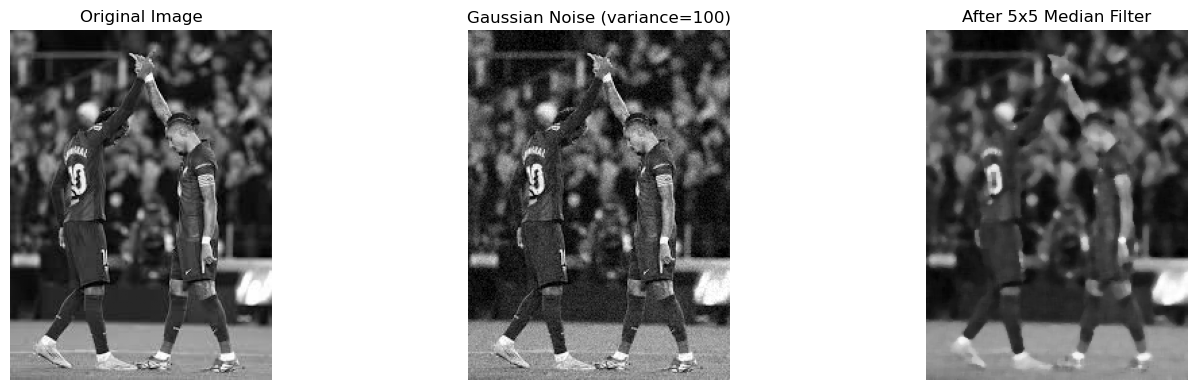

✓ Task 2.1 complete: Median filter effectively smooths Gaussian noise.


In [41]:
# Task 2.1: Gaussian noise + Median filter
np.random.seed(42)

# Add Gaussian noise (arbitrary parameters)
noisy_gaussian = add_gaussian_noise(image, mean=0, variance=100)

# Apply median filter
denoised_median = apply_median_filter(noisy_gaussian, filt_size=5)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(noisy_gaussian, cmap='gray')
axes[1].set_title('Gaussian Noise (variance=100)')
axes[1].axis('off')

axes[2].imshow(denoised_median, cmap='gray')
axes[2].set_title('After 5x5 Median Filter')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Task 2.1 complete: Median filter effectively smooths Gaussian noise.")

## Task 2.2 — Gaussian (low variance) + Mean & Geometric Mean Filters

Apply low-variance Gaussian noise (mean=0, variance=0.0009) and test 3x3 & 5x5 mean and geometric mean filters.

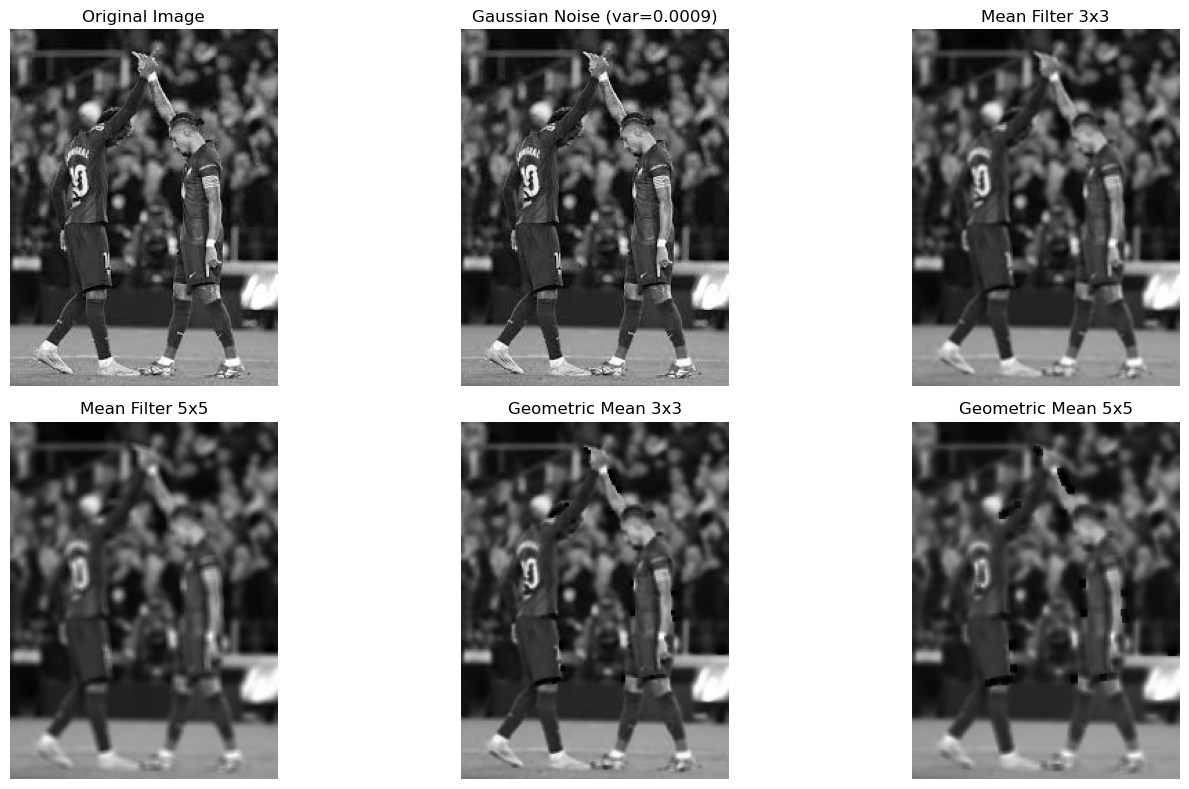

✓ Task 2.2 complete: Both mean filters improve low-variance Gaussian noise.


In [42]:
# Task 2.2: Gaussian (low variance) + Mean & Geometric Mean Filters
np.random.seed(42)

# Add low-variance Gaussian noise
noisy_low_var = add_gaussian_noise(image, mean=0, variance=0.0009)

# Apply filters
mean_3x3 = apply_mean_filter(noisy_low_var, filt_size=3)
mean_5x5 = apply_mean_filter(noisy_low_var, filt_size=5)
geom_3x3 = apply_geometric_mean_filter(noisy_low_var, filt_size=3)
geom_5x5 = apply_geometric_mean_filter(noisy_low_var, filt_size=5)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_low_var, cmap='gray')
axes[0, 1].set_title('Gaussian Noise (var=0.0009)')
axes[0, 1].axis('off')

axes[0, 2].imshow(mean_3x3, cmap='gray')
axes[0, 2].set_title('Mean Filter 3x3')
axes[0, 2].axis('off')

axes[1, 0].imshow(mean_5x5, cmap='gray')
axes[1, 0].set_title('Mean Filter 5x5')
axes[1, 0].axis('off')

axes[1, 1].imshow(geom_3x3, cmap='gray')
axes[1, 1].set_title('Geometric Mean 3x3')
axes[1, 1].axis('off')

axes[1, 2].imshow(geom_5x5, cmap='gray')
axes[1, 2].set_title('Geometric Mean 5x5')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Task 2.2 complete: Both mean filters improve low-variance Gaussian noise.")

## Task 2.3 — Gaussian (high variance) + Mean & Geometric Mean Filters

Apply high-variance Gaussian noise (mean=0, variance=0.09) and test filters with larger windows if needed.

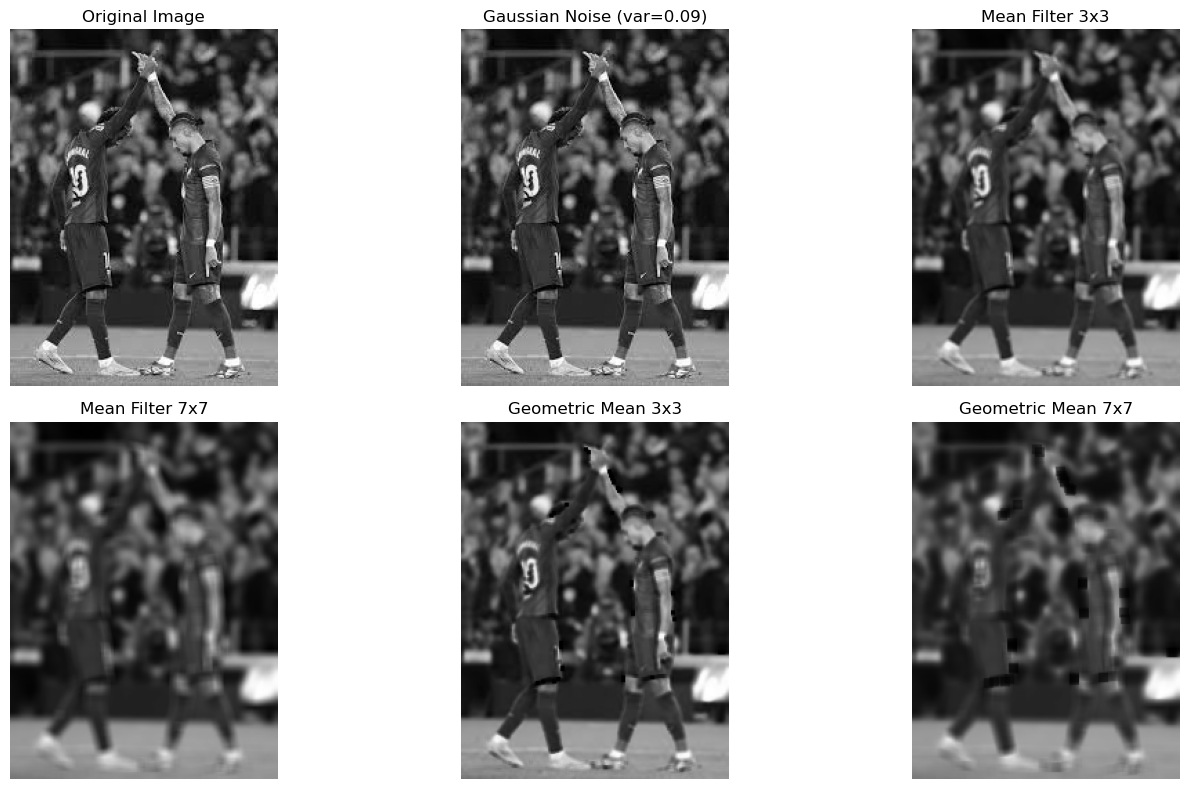

✓ Task 2.3 complete: Larger windows (7x7) better for high-variance Gaussian noise.


In [43]:
# Task 2.3: Gaussian (high variance) + Mean & Geometric Mean Filters
np.random.seed(42)

# Add high-variance Gaussian noise
noisy_high_var = add_gaussian_noise(image, mean=0, variance=0.09)

# Apply filters
mean_3x3_h = apply_mean_filter(noisy_high_var, filt_size=3)
mean_7x7_h = apply_mean_filter(noisy_high_var, filt_size=7)
geom_3x3_h = apply_geometric_mean_filter(noisy_high_var, filt_size=3)
geom_7x7_h = apply_geometric_mean_filter(noisy_high_var, filt_size=7)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_high_var, cmap='gray')
axes[0, 1].set_title('Gaussian Noise (var=0.09)')
axes[0, 1].axis('off')

axes[0, 2].imshow(mean_3x3_h, cmap='gray')
axes[0, 2].set_title('Mean Filter 3x3')
axes[0, 2].axis('off')

axes[1, 0].imshow(mean_7x7_h, cmap='gray')
axes[1, 0].set_title('Mean Filter 7x7')
axes[1, 0].axis('off')

axes[1, 1].imshow(geom_3x3_h, cmap='gray')
axes[1, 1].set_title('Geometric Mean 3x3')
axes[1, 1].axis('off')

axes[1, 2].imshow(geom_7x7_h, cmap='gray')
axes[1, 2].set_title('Geometric Mean 7x7')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Task 2.3 complete: Larger windows (7x7) better for high-variance Gaussian noise.")

## Task 2.4 — Salt & Pepper (0.1 prob both) + Median Filter

Apply salt & pepper noise and test 3x3 median filter.

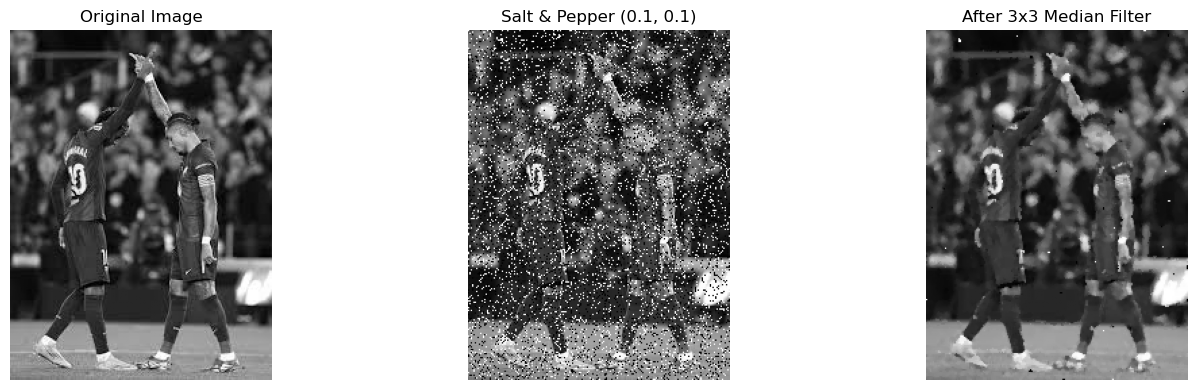

✓ Task 2.4 complete: 3x3 median filter effectively removes salt & pepper noise.


In [44]:
# Task 2.4: Salt & Pepper (0.1 both) + Median Filter
np.random.seed(42)

noisy_sp_01 = add_salt_pepper_noise(image, salt_prob=0.1, pepper_prob=0.1)
denoised_sp_01 = apply_median_filter(noisy_sp_01, filt_size=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(noisy_sp_01, cmap='gray')
axes[1].set_title('Salt & Pepper (0.1, 0.1)')
axes[1].axis('off')

axes[2].imshow(denoised_sp_01, cmap='gray')
axes[2].set_title('After 3x3 Median Filter')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Task 2.4 complete: 3x3 median filter effectively removes salt & pepper noise.")

## Task 2.5 — Salt & Pepper (0.2 prob both) + Multiple Median Filters

Apply heavier salt & pepper noise (0.2, 0.2) and compare 3x3, 5x5, 7x7, and 3x3 with 4 iterations.

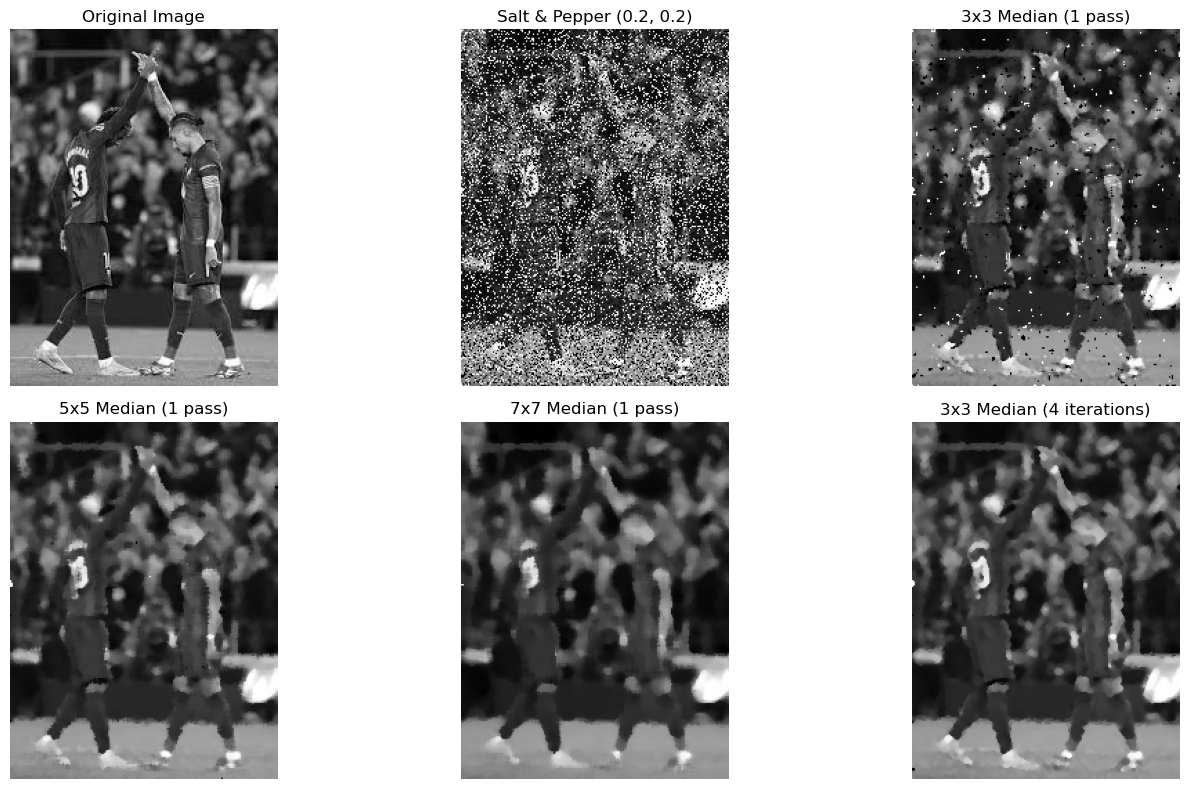

✓ Task 2.5 complete: Multiple iterations or larger windows handle heavy salt & pepper noise.


In [45]:
# Task 2.5: Salt & Pepper (0.2 both) + Multiple Median Filters
np.random.seed(42)

noisy_sp_02 = add_salt_pepper_noise(image, salt_prob=0.2, pepper_prob=0.2)

# Single pass with different window sizes
median_3x3 = apply_median_filter(noisy_sp_02, filt_size=3)
median_5x5 = apply_median_filter(noisy_sp_02, filt_size=5)
median_7x7 = apply_median_filter(noisy_sp_02, filt_size=7)

# Multiple iterations with 3x3
median_3x3_iter2 = apply_median_filter(median_3x3, filt_size=3)
median_3x3_iter3 = apply_median_filter(median_3x3_iter2, filt_size=3)
median_3x3_iter4 = apply_median_filter(median_3x3_iter3, filt_size=3)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_sp_02, cmap='gray')
axes[0, 1].set_title('Salt & Pepper (0.2, 0.2)')
axes[0, 1].axis('off')

axes[0, 2].imshow(median_3x3, cmap='gray')
axes[0, 2].set_title('3x3 Median (1 pass)')
axes[0, 2].axis('off')

axes[1, 0].imshow(median_5x5, cmap='gray')
axes[1, 0].set_title('5x5 Median (1 pass)')
axes[1, 0].axis('off')

axes[1, 1].imshow(median_7x7, cmap='gray')
axes[1, 1].set_title('7x7 Median (1 pass)')
axes[1, 1].axis('off')

axes[1, 2].imshow(median_3x3_iter4, cmap='gray')
axes[1, 2].set_title('3x3 Median (4 iterations)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Task 2.5 complete: Multiple iterations or larger windows handle heavy salt & pepper noise.")